# DCCD maps for best-completion model

This notebook selects the model with the highest `task_completion_pct` under `results/dccd_bt_all_tasks/` and plots **maps only** for a chosen task.

It mirrors the map behavior of `tree&map_per_model.ipynb`, but filters to the single best model and does not print trees.


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def find_project_root(start: Path | None = None) -> Path:
    base = (start or Path.cwd()).resolve()
    for candidate in [base, *base.parents]:
        if (candidate / "src" / "tasks" / "tasks_100.json").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


ROOT_DIR = find_project_root()
RESULTS_DIR = ROOT_DIR / "results"
TASKS_PATH = ROOT_DIR / "src" / "tasks" / "tasks_100.json"


def load_task_env(task_id: str) -> dict:
    tasks = json.loads(TASKS_PATH.read_text(encoding="utf-8"))
    for task in tasks:
        if task.get("task_id") == task_id:
            world = task["world"]
            return {
                "task_id": task["task_id"],
                "task_type": task["task_type"],
                "obstacles": world.get("obstacles", []),
                "targets": world.get("targets", []),
            }
    raise ValueError(f"Task not found: {task_id}")


def get_best_completion_model(run_id: str) -> dict:
    results_dir = RESULTS_DIR / run_id
    if not results_dir.exists():
        raise FileNotFoundError(f"Missing results folder: {results_dir}")

    best_row = None
    for model_dir in sorted(path for path in results_dir.iterdir() if path.is_dir()):
        main_path = model_dir / "main_results.json"
        if not main_path.exists():
            continue

        main = json.loads(main_path.read_text(encoding="utf-8"))
        row = {
            "model_dir": model_dir,
            "model_id": main.get("model_id", model_dir.name),
            "completed": int(main.get("total_task_completion", 0)),
            "total_tasks": int(main.get("total_tasks", 0)),
            "completion_pct": float(main.get("task_completion_pct", 0.0)),
        }

        if best_row is None:
            best_row = row
            continue

        if row["completion_pct"] > best_row["completion_pct"]:
            best_row = row
        elif row["completion_pct"] == best_row["completion_pct"]:
            if row["completed"] > best_row["completed"]:
                best_row = row

    if best_row is None:
        raise ValueError(f"No model main_results.json found under: {results_dir}")

    return best_row


def _draw_environment(ax, task_env: dict) -> None:
    for obstacle in task_env["obstacles"]:
        rect = Rectangle(
            (obstacle["x1"], obstacle["y1"]),
            obstacle["x2"] - obstacle["x1"],
            obstacle["y2"] - obstacle["y1"],
            facecolor="black",
            alpha=0.35,
            edgecolor="black",
        )
        ax.add_patch(rect)

    for target in task_env["targets"]:
        rect = Rectangle(
            (target["x1"], target["y1"]),
            target["x2"] - target["x1"],
            target["y2"] - target["y1"],
            facecolor="limegreen",
            alpha=0.3,
            edgecolor="green",
        )
        ax.add_patch(rect)


def _extract_points(task_result: dict) -> list[tuple[float, float]]:
    points = [(0.0, 0.0)]

    for tree in task_result.get("behavior_trees", []):
        final_spot = (tree.get("plan_results") or {}).get("final_spot")
        if isinstance(final_spot, dict) and "x" in final_spot and "y" in final_spot:
            points.append((float(final_spot["x"]), float(final_spot["y"])))

    if len(points) == 1:
        final_spot = task_result.get("final_spot", {"x": 0.0, "y": 0.0})
        points.append((float(final_spot.get("x", 0.0)), float(final_spot.get("y", 0.0))))

    return points


def _plot_one_task_map(best: dict, task_id: str, task_result: dict) -> dict:
    task_env = load_task_env(task_id)
    points = _extract_points(task_result)

    fig, ax = plt.subplots(figsize=(7, 6))
    _draw_environment(ax, task_env)

    # Color each BT attempt segment: 1=blue, 2=green, 3=yellow.
    tree_colors = ["tab:blue", "tab:green", "gold"]
    for idx in range(1, len(points)):
        x0, y0 = points[idx - 1]
        x1, y1 = points[idx]
        color = tree_colors[(idx - 1) % len(tree_colors)]
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=2, marker="o")

    ax.scatter([points[0][0]], [points[0][1]], c="tab:blue", s=70, label="start")
    ax.scatter([points[-1][0]], [points[-1][1]], c="red", s=80, marker="x", label="last")

    task_done = bool(task_result.get("task_completion", False))
    done_text = "done" if task_done else "not done"
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{best['model_id']} | {task_id} | {done_text}")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    plt.show()

    return {
        "task_id": task_id,
        "task_completion": task_done,
        "bt_count": len(task_result.get("behavior_trees", [])),
    }


def plot_all_maps_for_best_model(run_id: str) -> dict:
    best = get_best_completion_model(run_id)
    tasks_dir = best["model_dir"] / "tasks"
    if not tasks_dir.exists():
        raise FileNotFoundError(f"Missing tasks directory for best model: {tasks_dir}")

    task_files = sorted(tasks_dir.glob("task_*.json"), key=lambda p: p.stem)
    if not task_files:
        raise ValueError(f"No task files found under: {tasks_dir}")

    print(
        f"Best model: {best['model_id']} | "
        f"completion: {best['completed']}/{best['total_tasks']} "
        f"({best['completion_pct']:.2f}%)"
    )
    print(f"Plotting {len(task_files)} task maps...")

    summaries = []
    for task_file in task_files:
        task_id = task_file.stem.removeprefix("task_")
        task_result = json.loads(task_file.read_text(encoding="utf-8"))
        summaries.append(_plot_one_task_map(best, task_id, task_result))

    completed = sum(1 for s in summaries if s["task_completion"])
    print(f"Rendered {len(summaries)} maps | completed: {completed}/{len(summaries)}")

    return {
        "model_id": best["model_id"],
        "completion_pct": best["completion_pct"],
        "num_tasks_plotted": len(summaries),
        "num_completed_tasks": completed,
    }


Best model: Qwen/Qwen2.5-7B-Instruct | completion: 19/100 (19.00%)
Plotting 100 task maps...


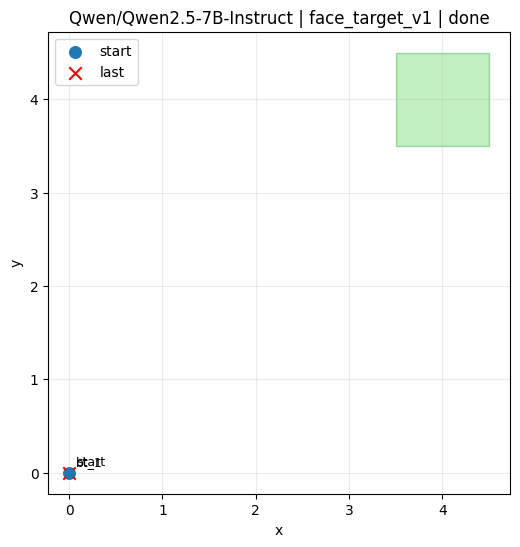

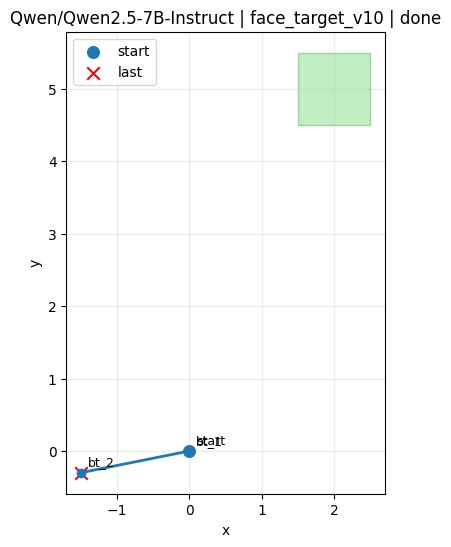

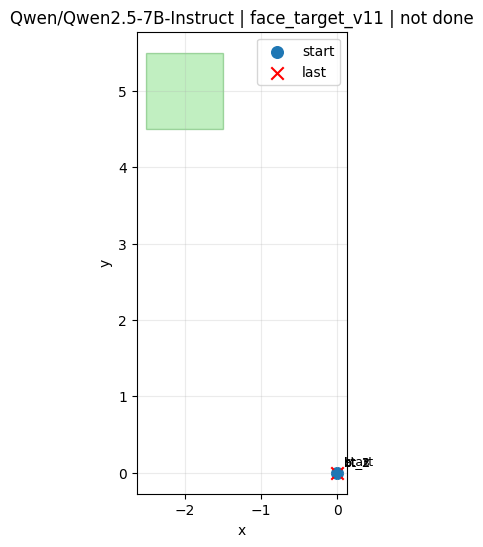

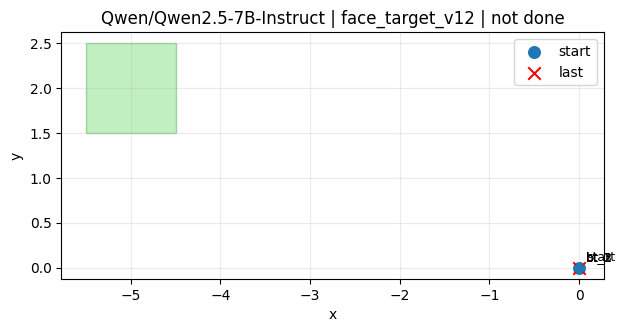

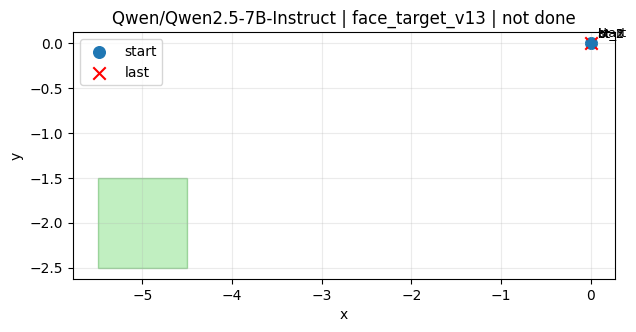

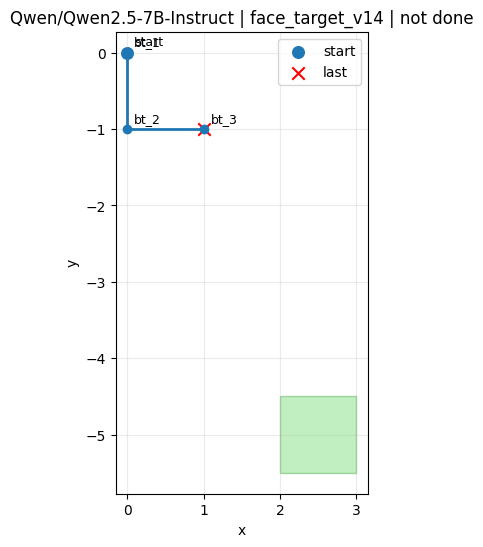

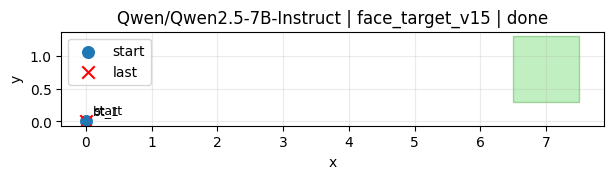

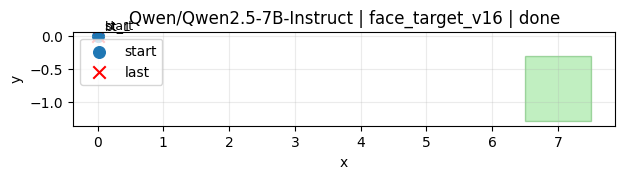

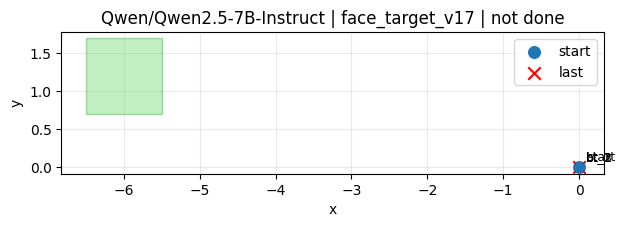

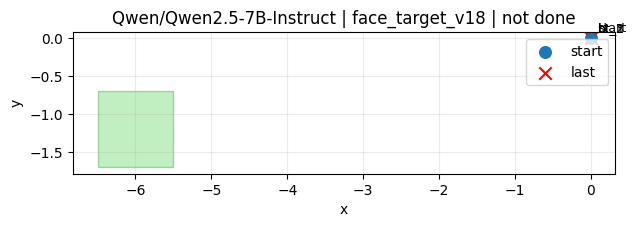

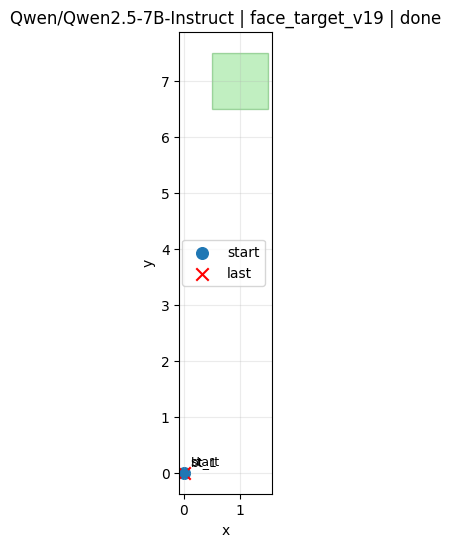

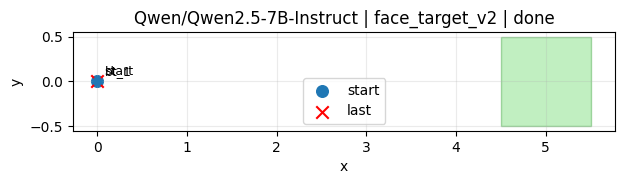

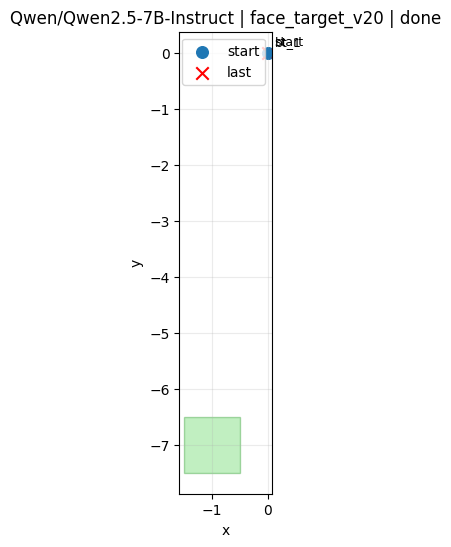

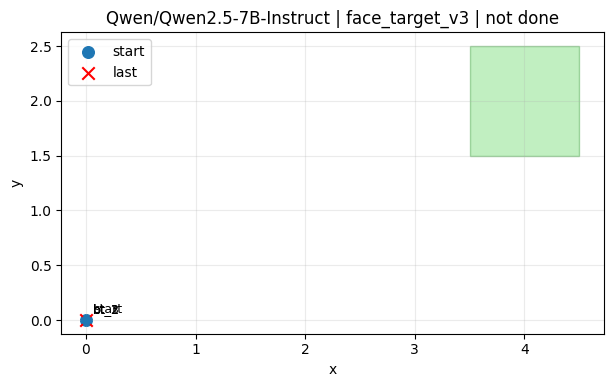

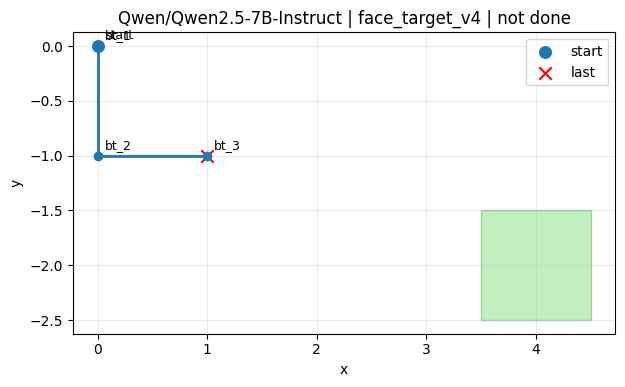

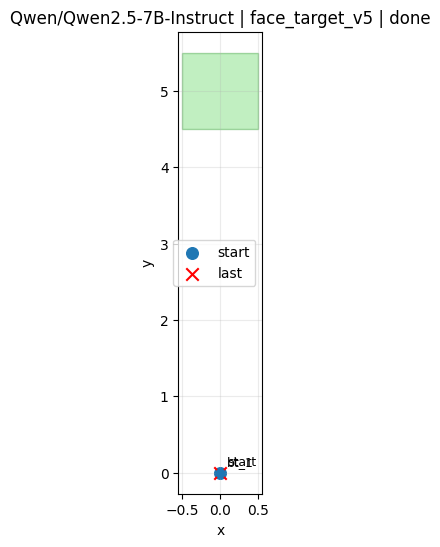

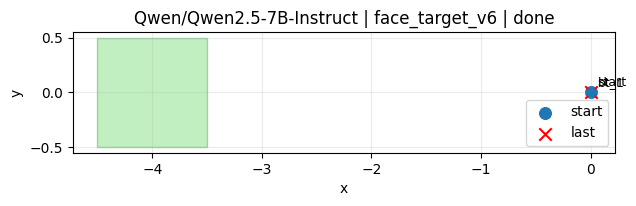

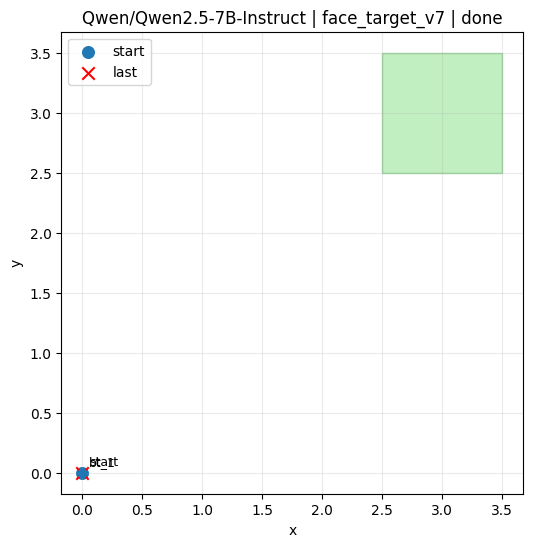

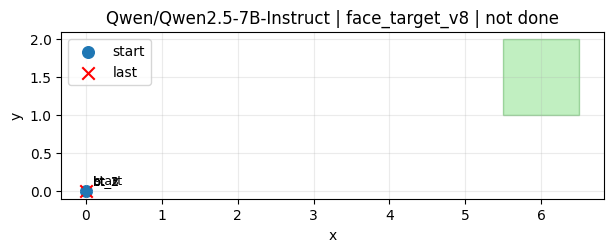

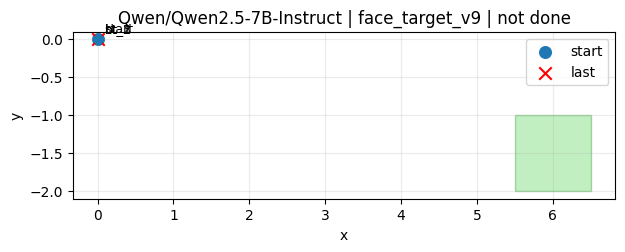

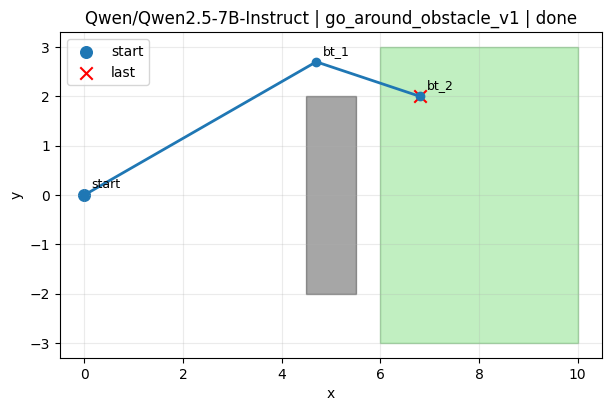

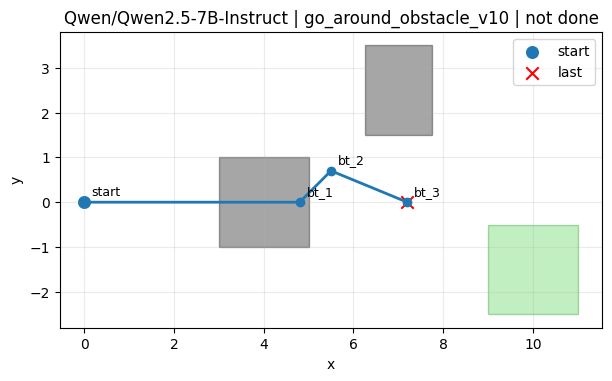

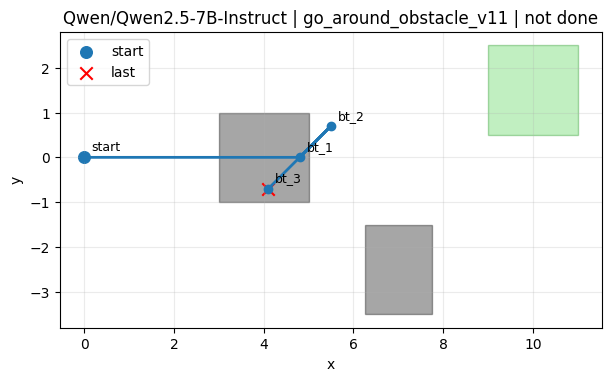

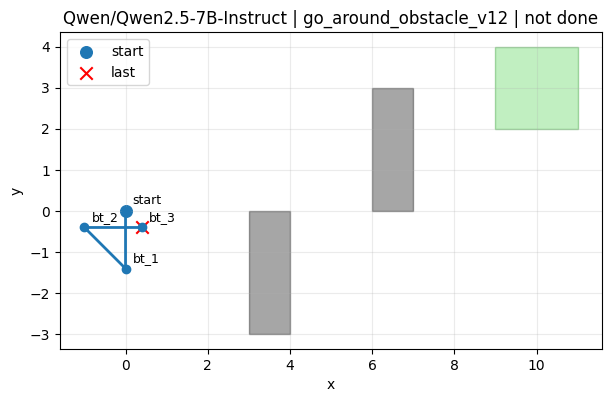

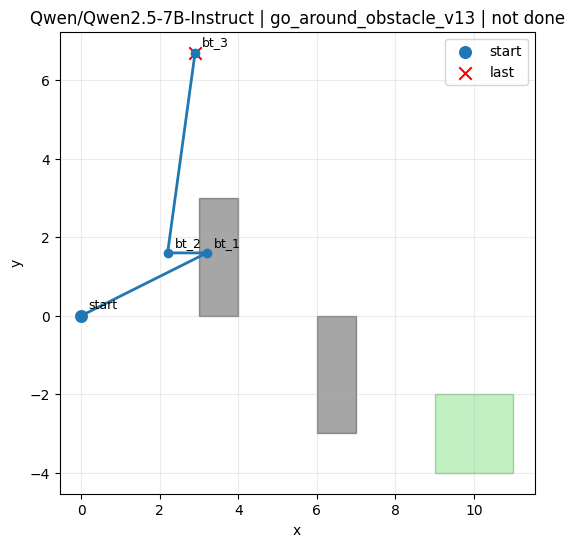

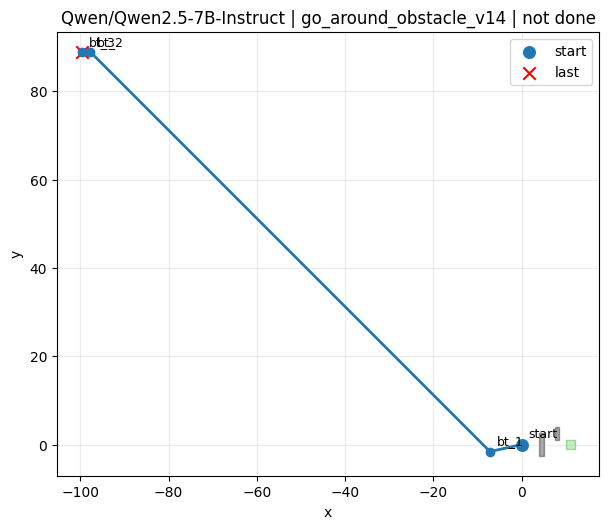

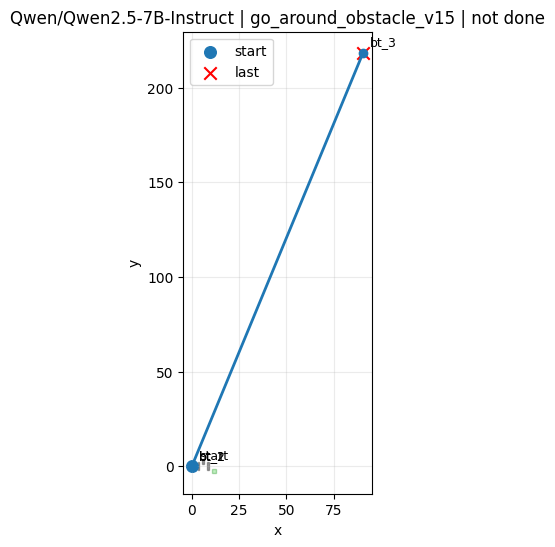

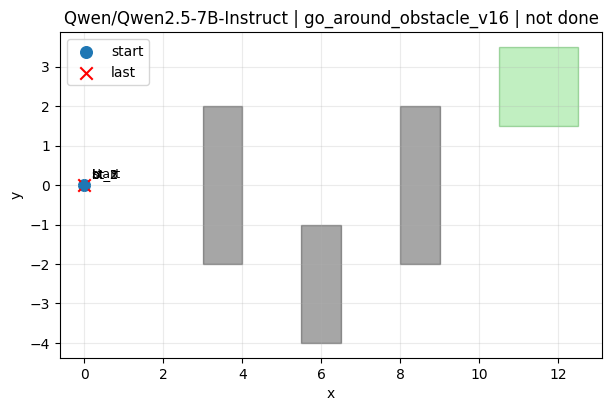

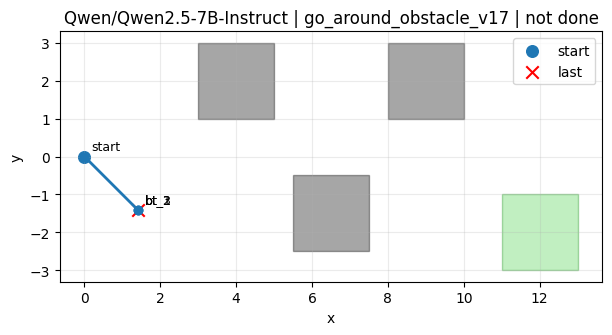

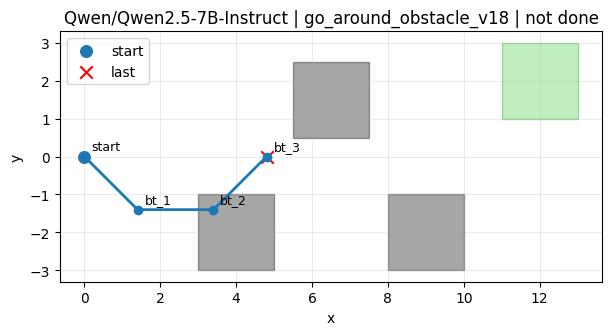

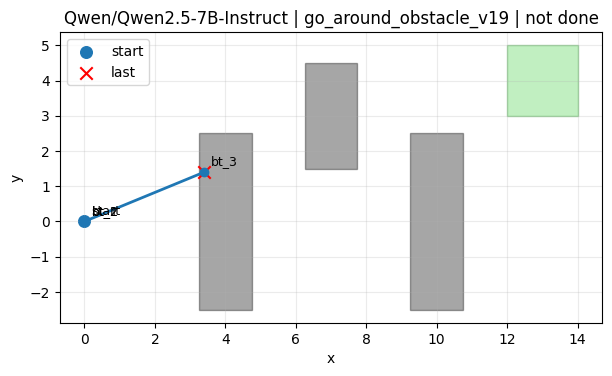

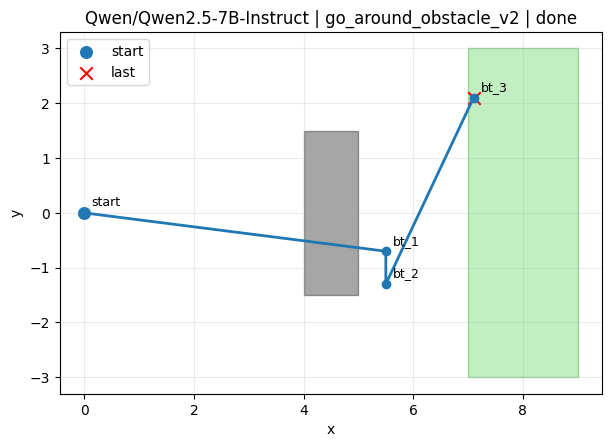

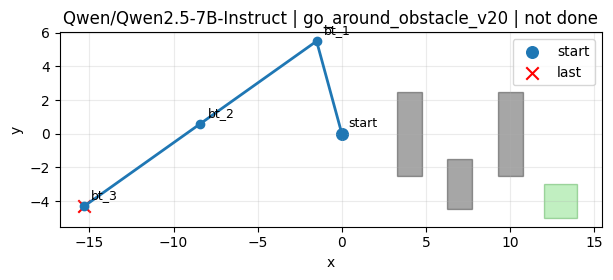

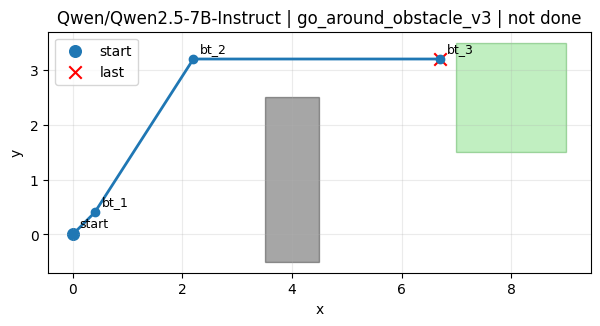

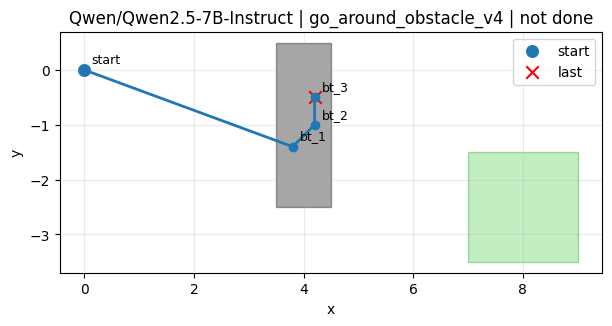

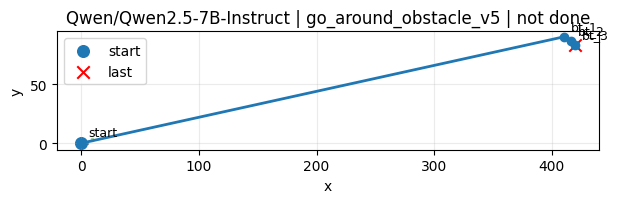

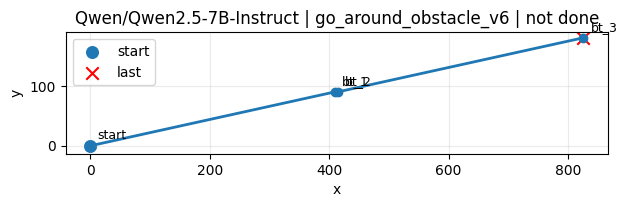

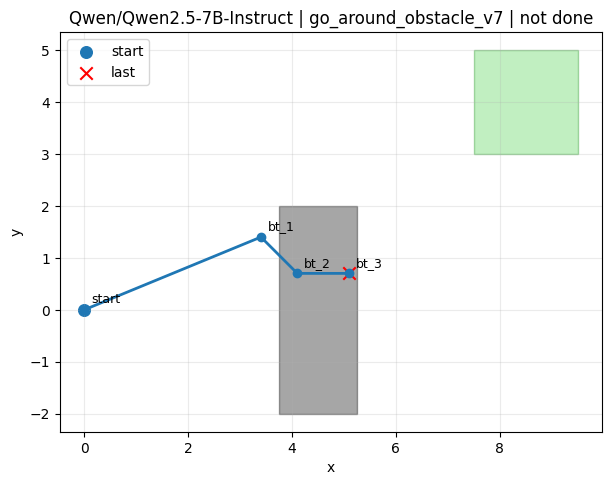

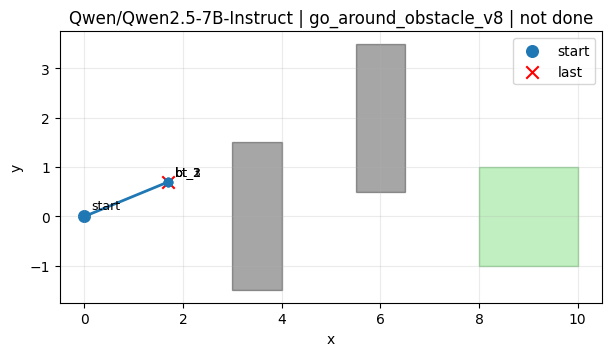

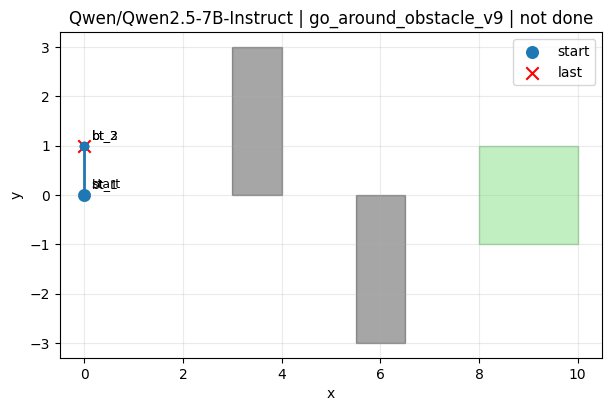

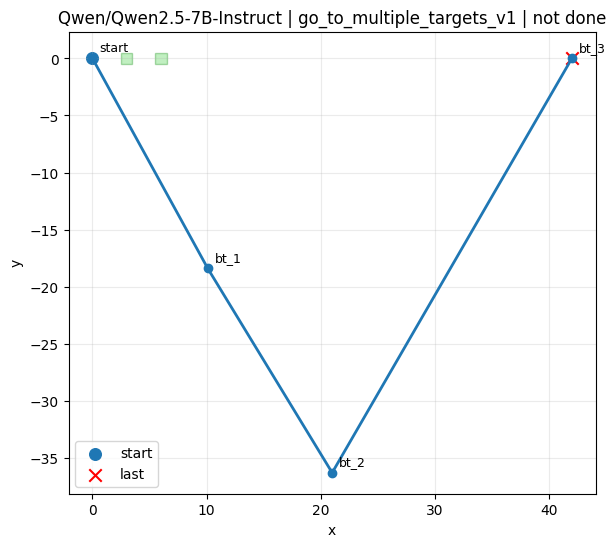

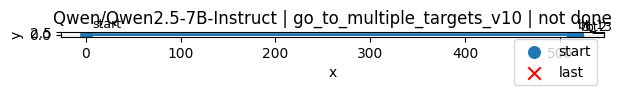

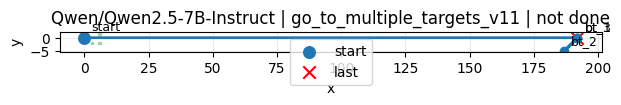

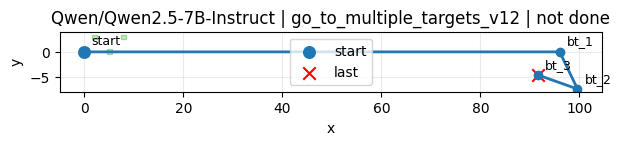

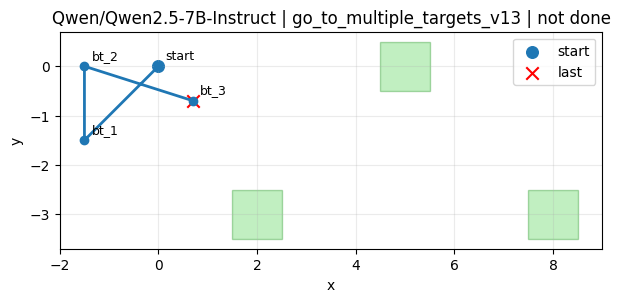

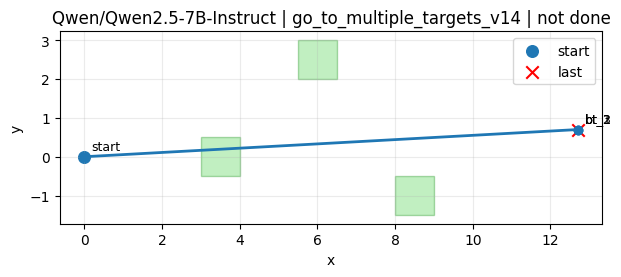

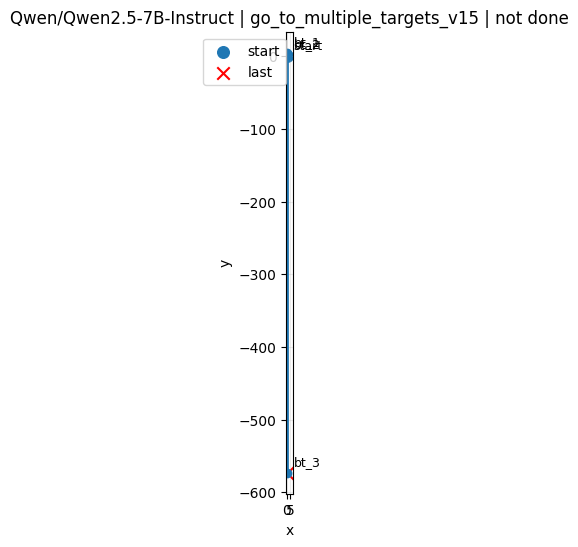

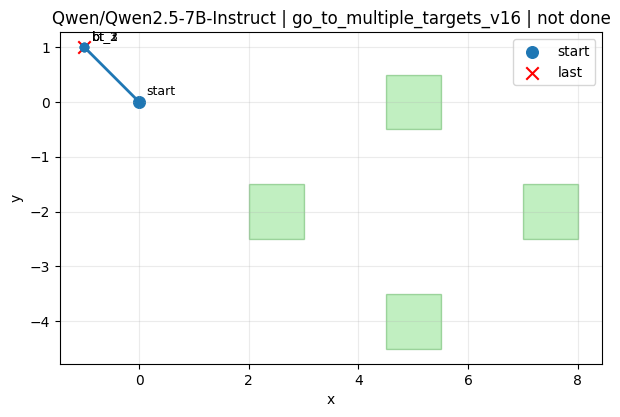

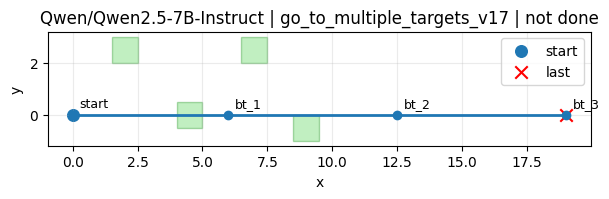

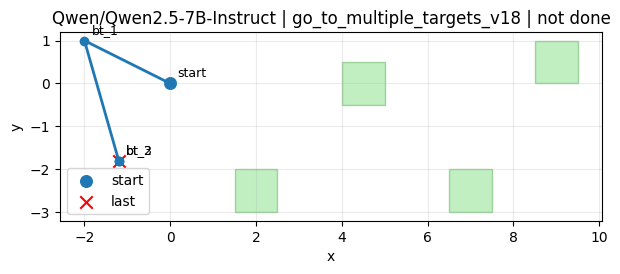

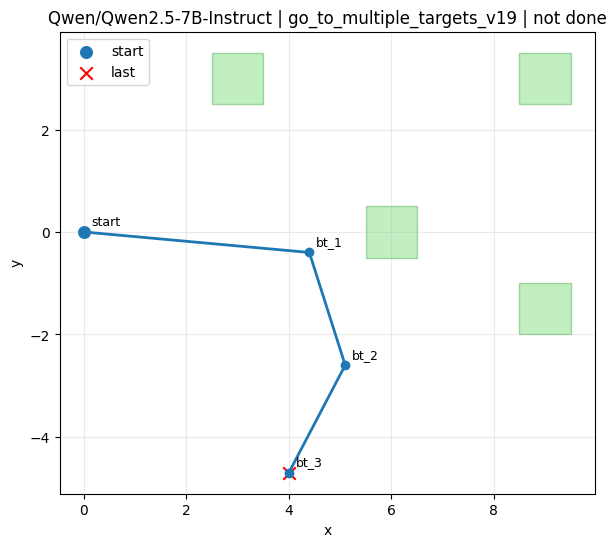

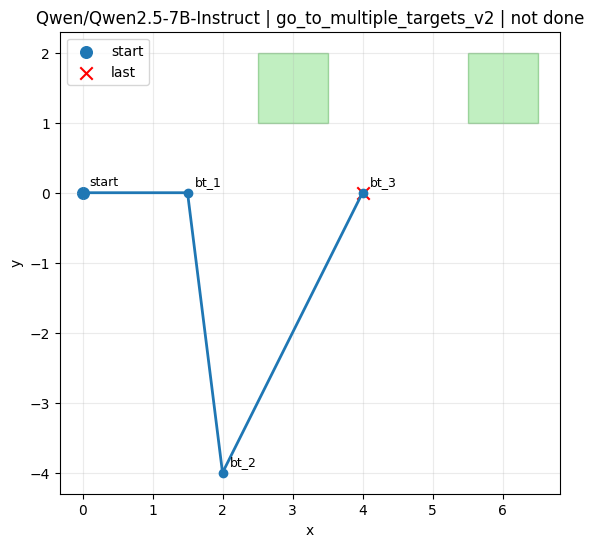

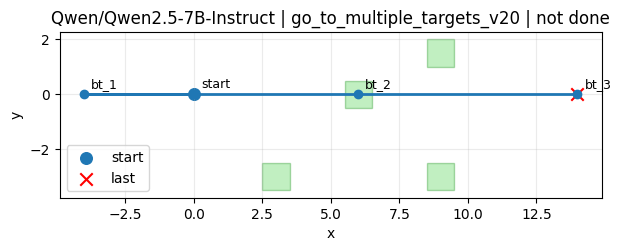

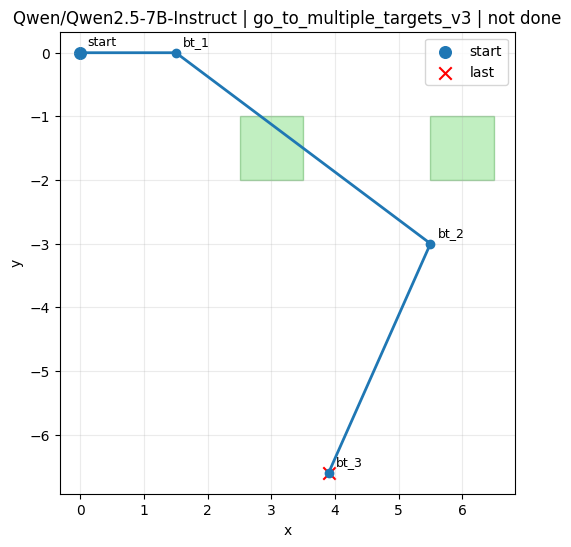

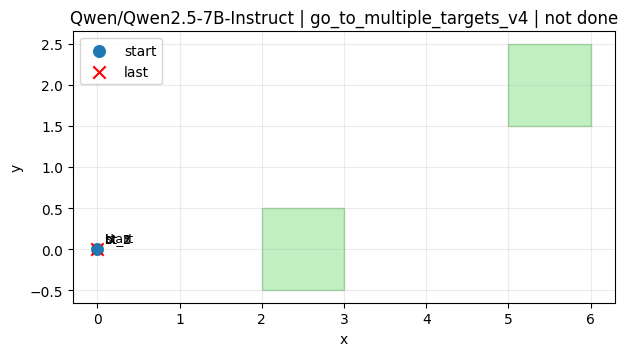

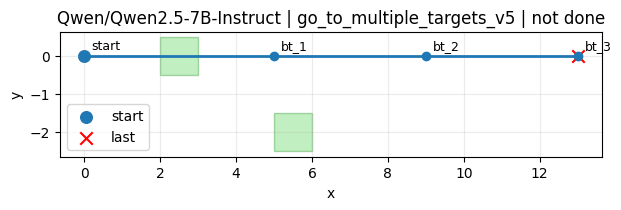

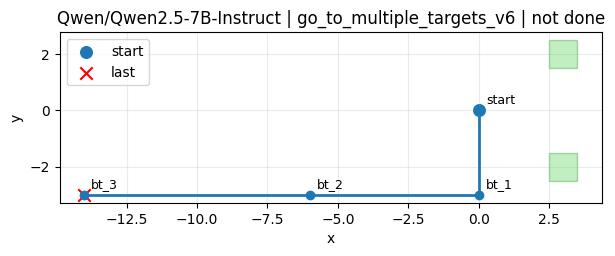

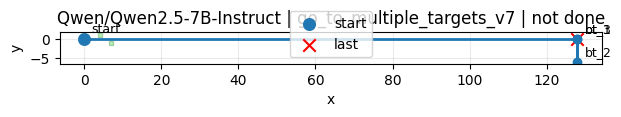

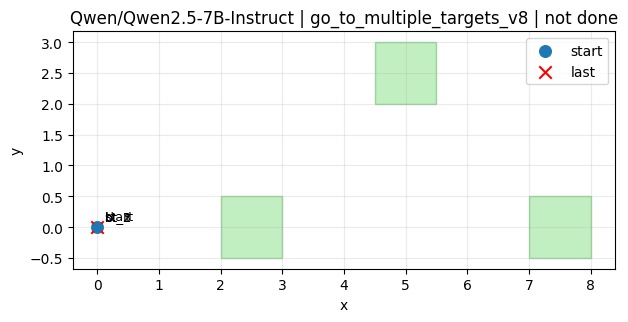

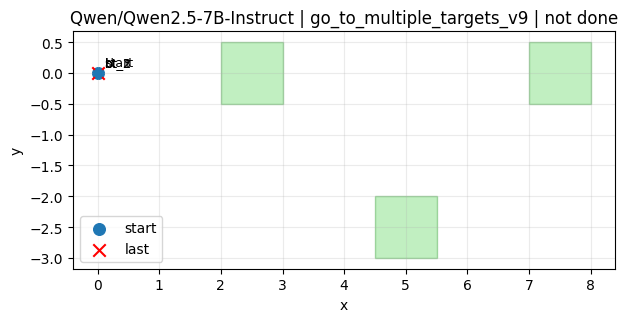

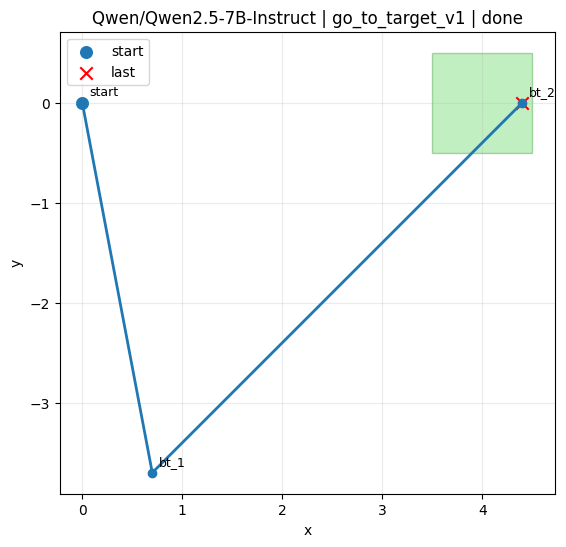

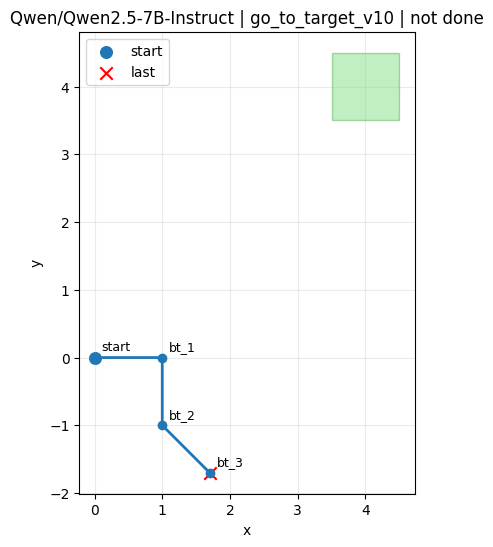

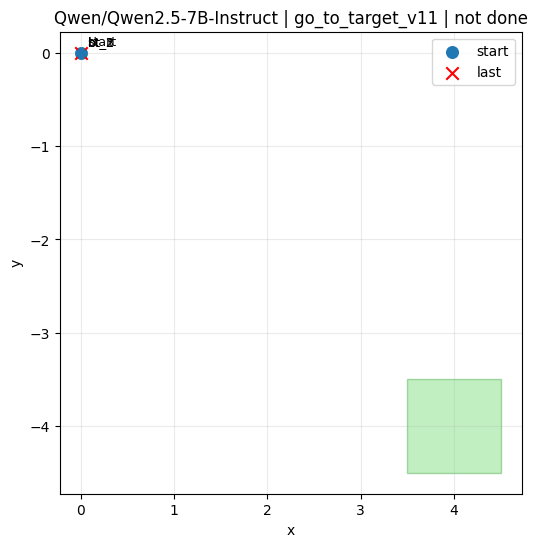

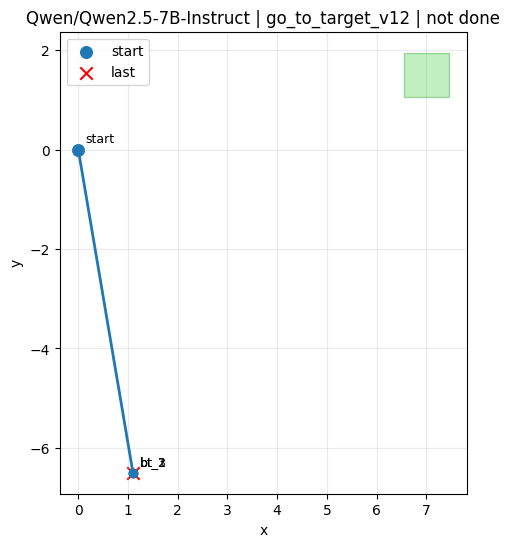

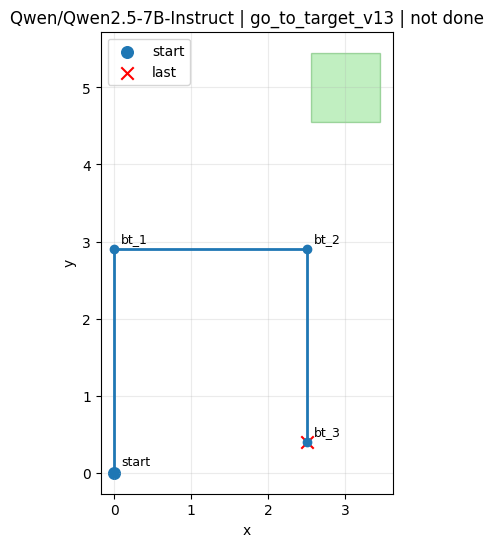

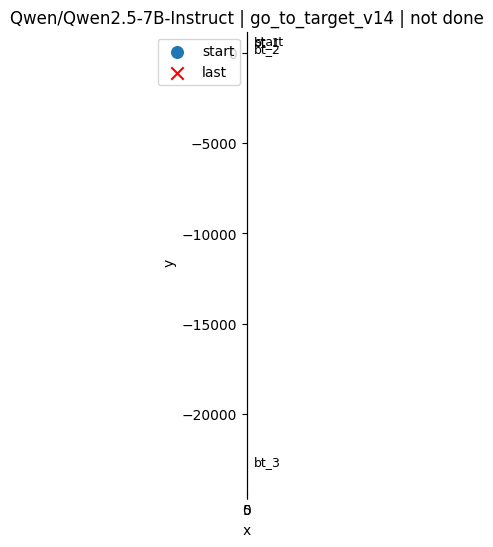

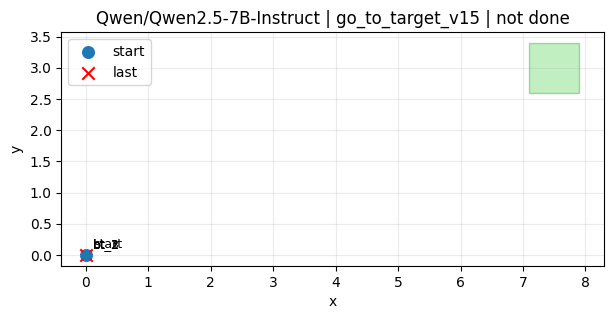

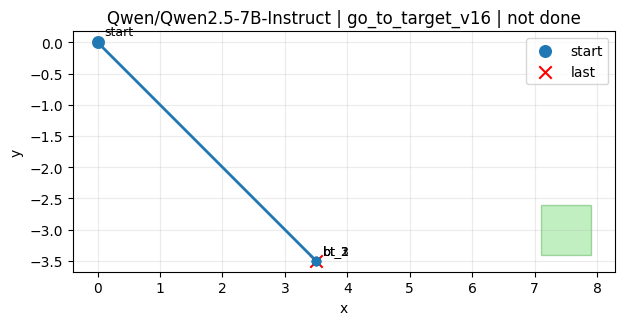

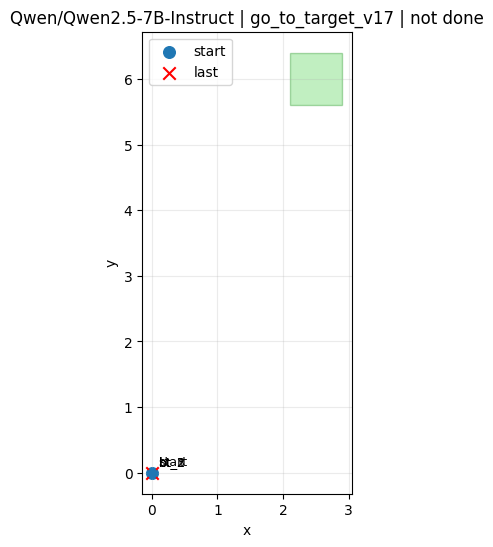

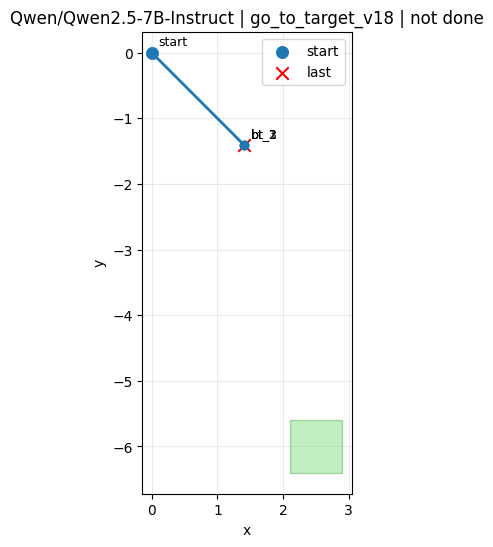

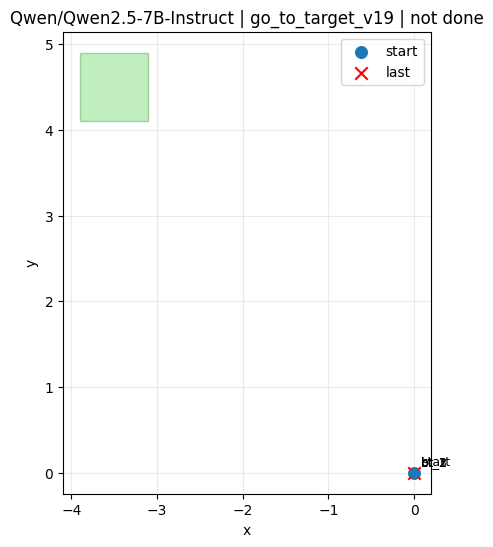

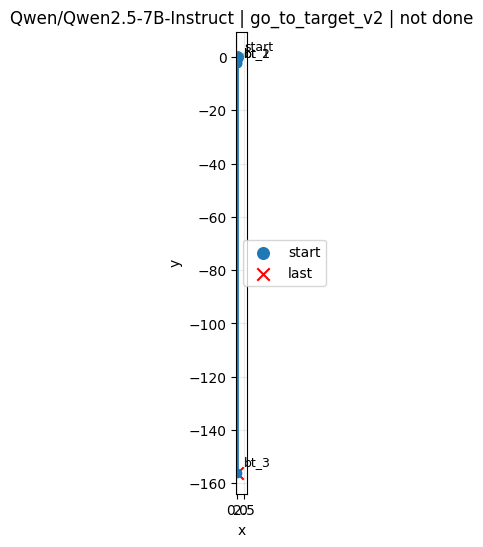

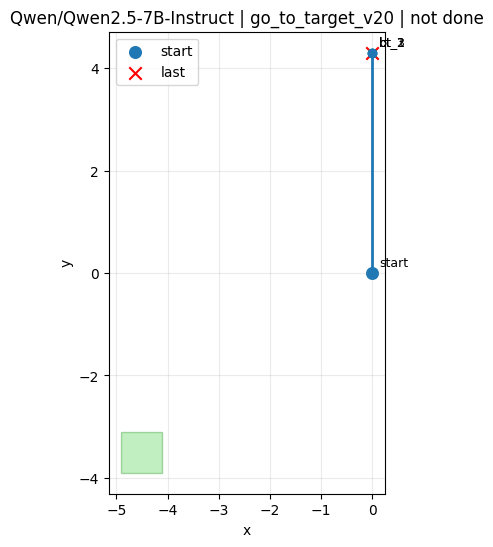

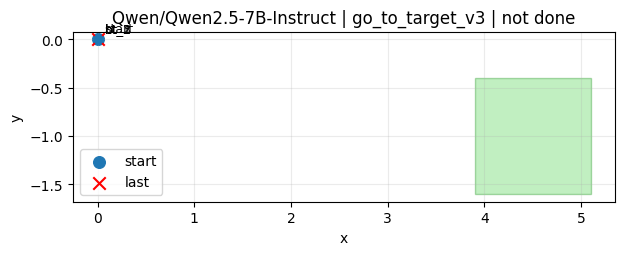

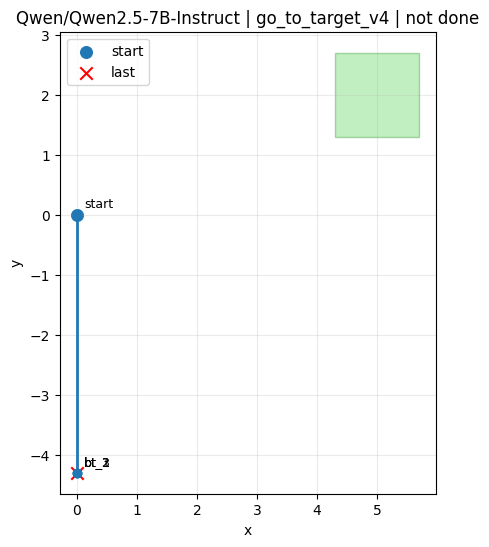

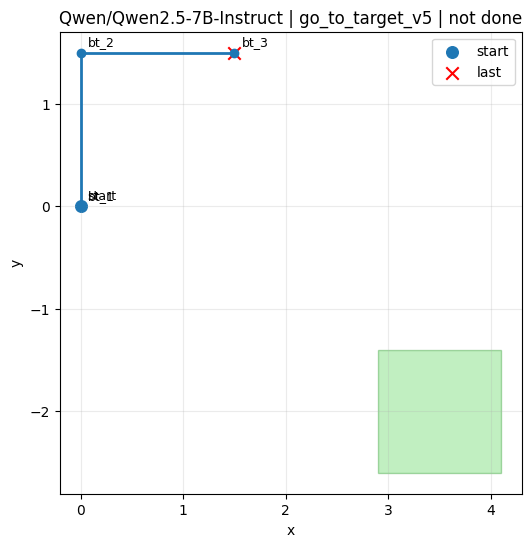

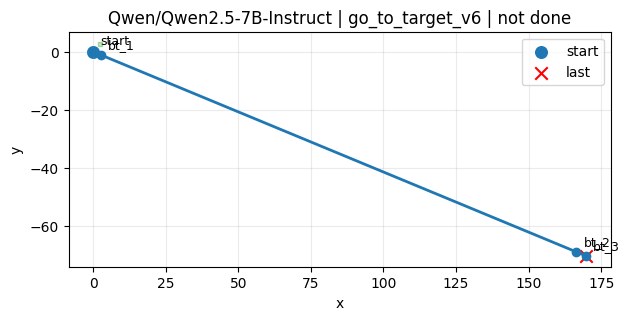

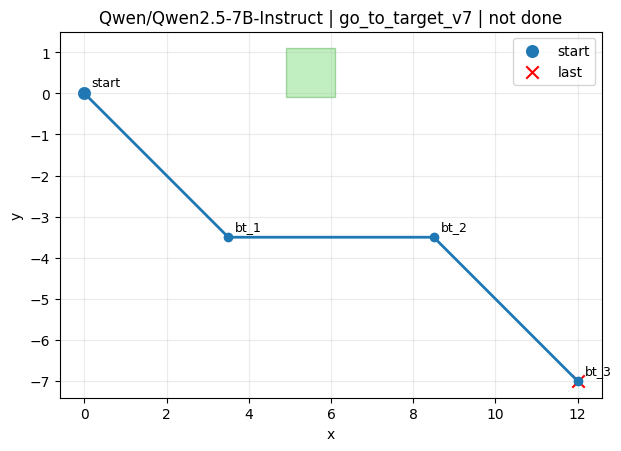

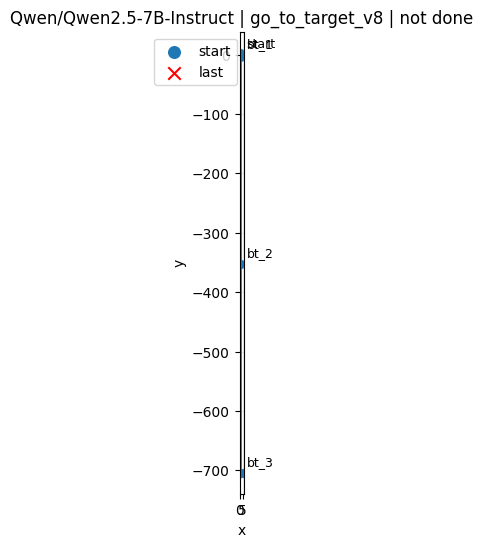

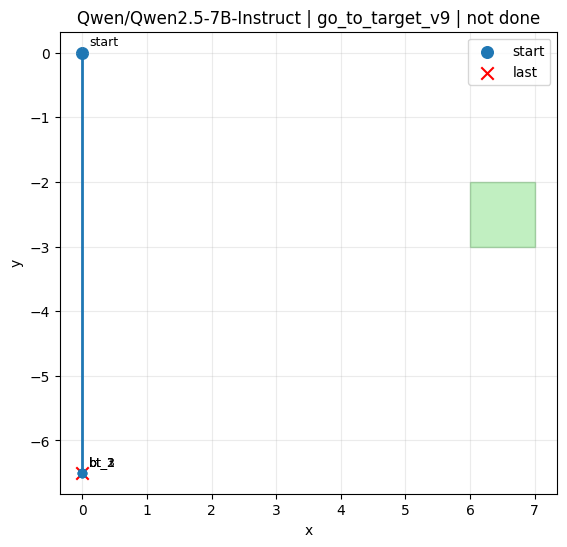

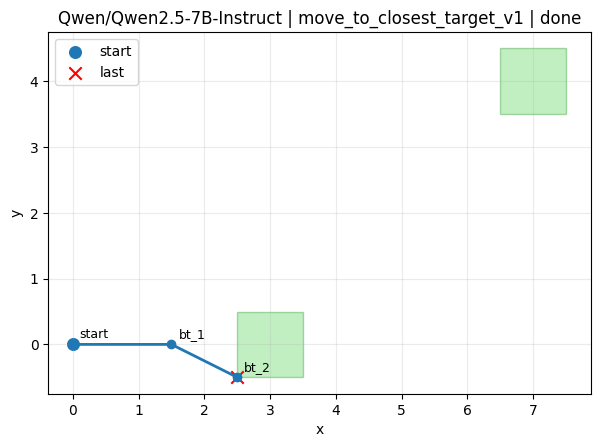

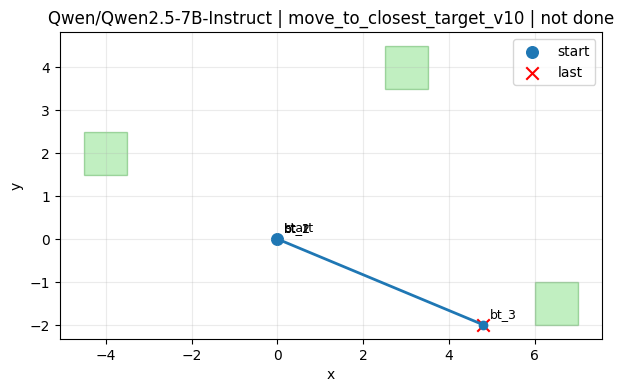

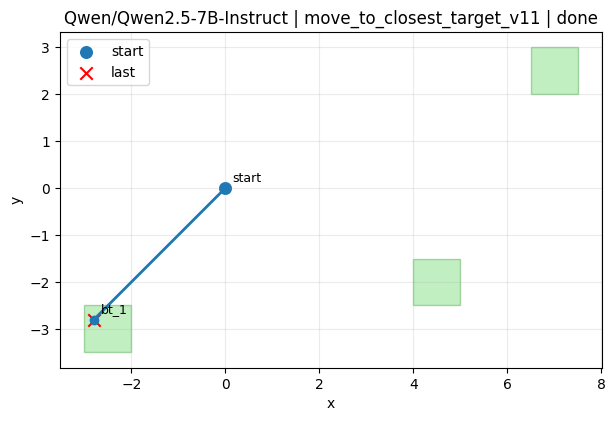

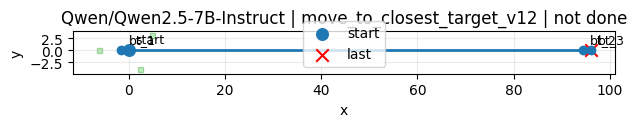

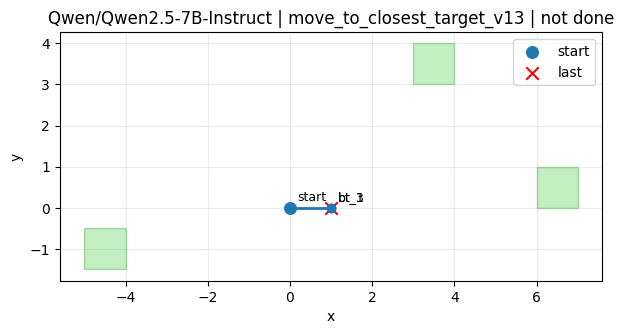

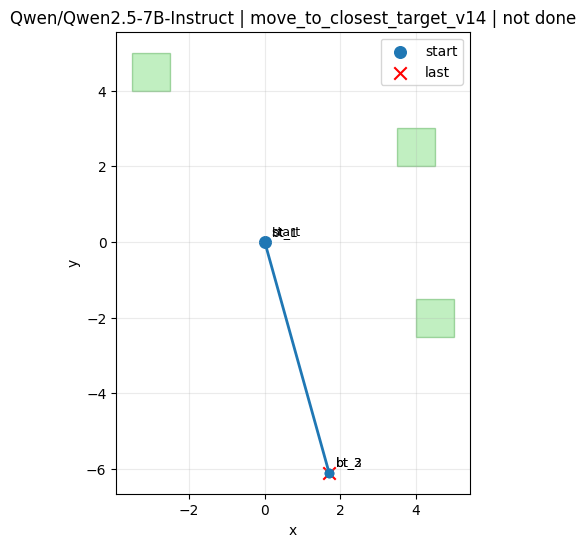

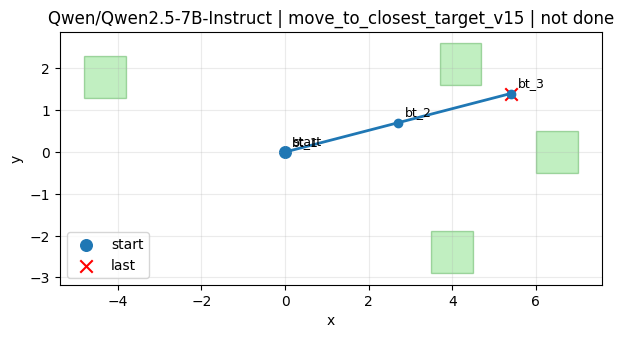

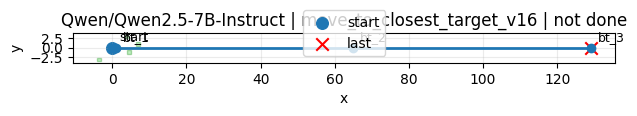

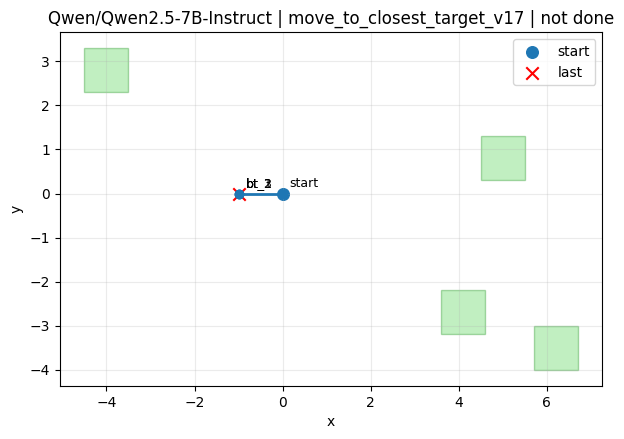

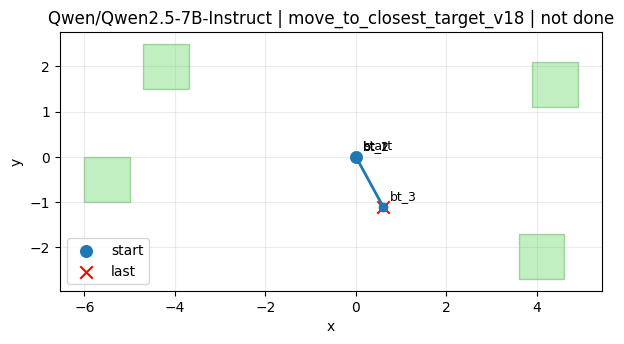

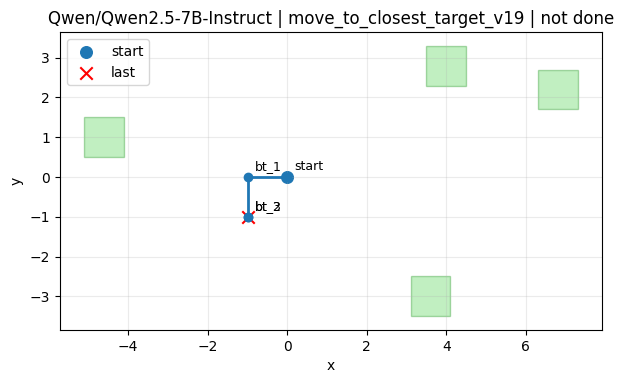

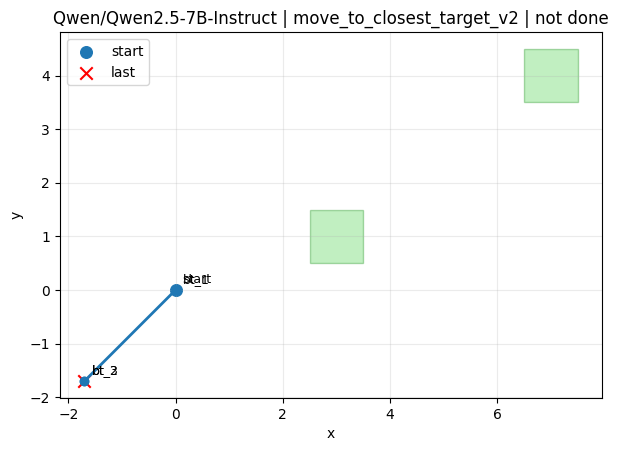

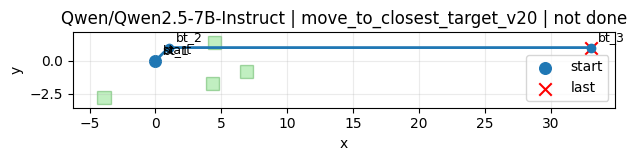

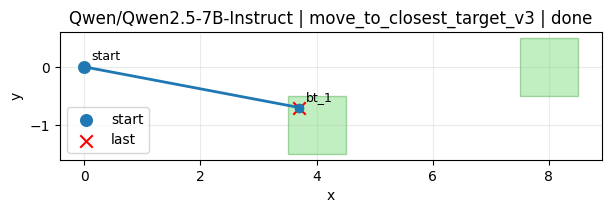

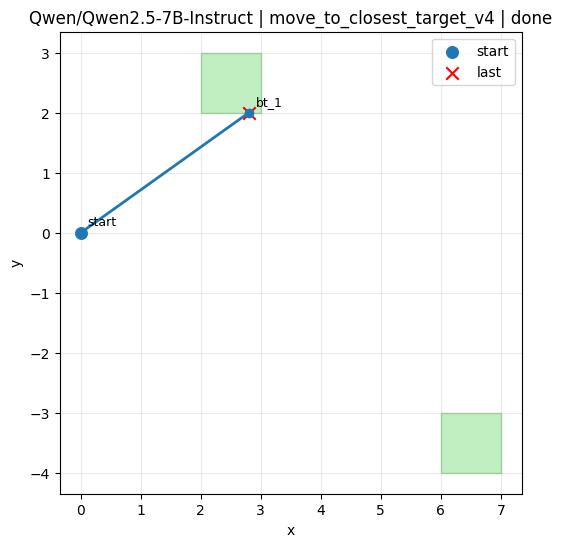

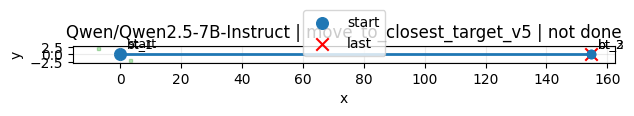

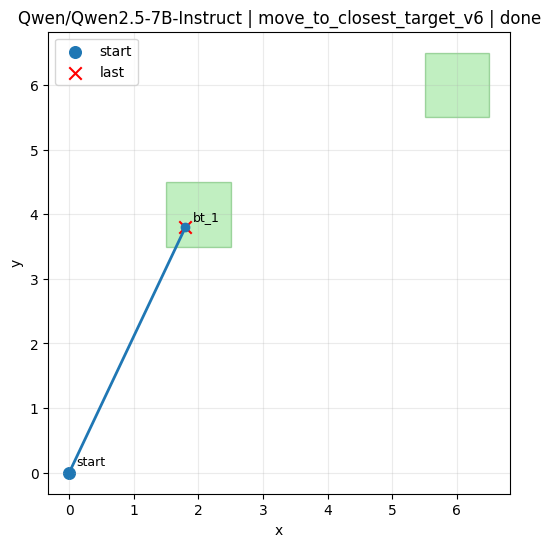

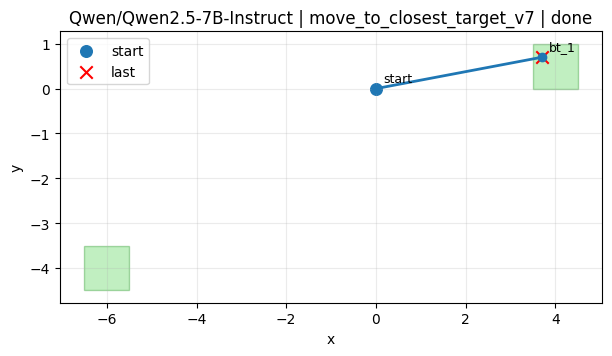

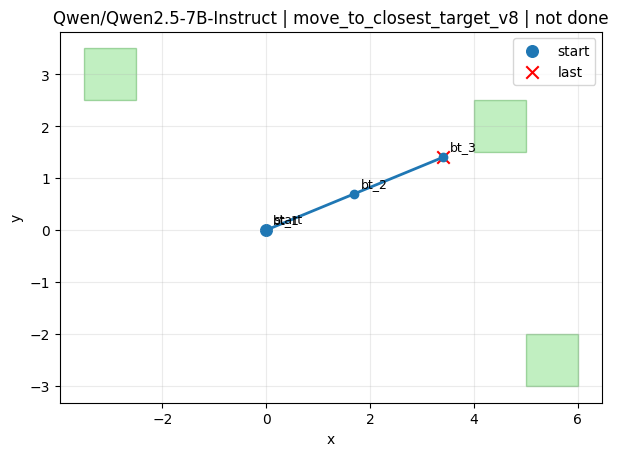

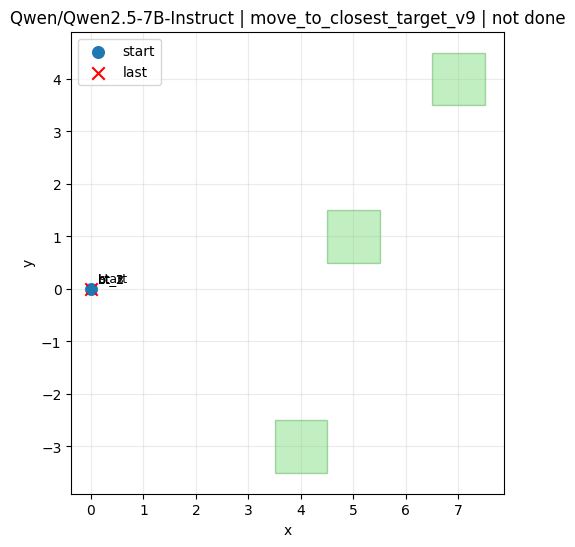

Rendered 100 maps | completed: 19/100


{'model_id': 'Qwen/Qwen2.5-7B-Instruct',
 'completion_pct': 19.0,
 'num_tasks_plotted': 100,
 'num_completed_tasks': 19}

In [5]:
plot_all_maps_for_best_model(
    run_id="dccd_bt_all_tasks",
)
